 ## **DATA ANALYSIS PYTHON PROJECTS -- BLINKIT ANALYSIS** by kundan kudoz

#### **Import libraries**

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("hello  world !")
print("here is kundan")

hello  world !
here is kundan


In [60]:
df=pd.read_csv(r"D:\move_data C to d\blinkit data.csv")

#### **Sample Data**

In [61]:
df.head(12)

,Item_Fat_Content,Item_Identifier,Item_Type,Outlet_Establishment_Year,Outlet_Identifier,Outlet Location Type,Outlet_Size,Outlet_Type,Item_Visibility,Item_Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier_1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2014,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


df.tail(12)

#### **Size of Data**

In [62]:
print("size of data ", df.shape)

size of data  (8523, 12)


#### **Field Info**

In [63]:
df.columns

Index(['Item_Fat_Content', 'Item_Identifier', 'Item_Type',
       'Outlet_Establishment_Year', 'Outlet_Identifier',
       'Outlet Location Type', 'Outlet_Size', 'Outlet_Type', 'Item_Visibility',
       'Item_Weight', 'Sales', 'Rating'],
      dtype='object')

#### **Check Data Types**

In [64]:
df.dtypes

Item_Fat_Content              object
Item_Identifier               object
Item_Type                     object
Outlet_Establishment_Year      int64
Outlet_Identifier             object
Outlet Location Type          object
Outlet_Size                   object
Outlet_Type                   object
Item_Visibility              float64
Item_Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

#### **Data Cleaning**

In [65]:
print(df['Item_Fat_Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [66]:
df['Item_Fat_Content']= df['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

In [67]:
df['Outlet Location Type']= df['Outlet Location Type'].replace({'Tier_1':'Tier 1'})

In [68]:
print(df['Outlet Location Type'].unique())

['Tier 1' 'Tier 3' 'Tier 2']


#### **Business Recquirements**

#### **Kpi's RECQUIREMENTS**

In [69]:
# total  Sales
total_Sales = df['Sales'].sum()

# Average Sales
AVG_Sales= df['Sales'].mean()

#NO of Item Sold
NO_Of_Item_Sold= df['Sales'].count()

 #Average Ratings
Avg_Rating= df['Rating'].mean()

# display

print(f"Total Sales: ${total_Sales:,.2f}")
print(f"Average Sales: ${AVG_Sales:,.2f}")
print(f"Total Item sold: ${NO_Of_Item_Sold:,.2f}")
print(f"Average Rating: ${Avg_Rating:,.2f}")

Total Sales: $1,201,681.49
Average Sales: $140.99
Total Item sold: $8,523.00
Average Rating: $3.97


## **CHARTS RECQUIREMENTS **

# Total Sales by Fat Conntent

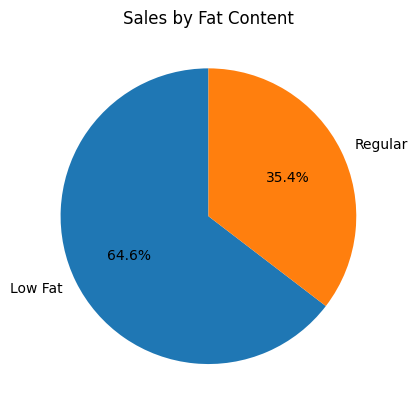

In [70]:


# Group sales by fat content
sales_by_fat = df.groupby('Item_Fat_Content')['Sales'].sum()

# Plot pie chart
plt.pie(
    sales_by_fat.values, 
    labels=sales_by_fat.index,
    autopct='%.1f%%',
    startangle=90
)

plt.title('Sales by Fat Content')
plt.gca().set_aspect('equal')  # Ensures the pie is a circle
plt.show()


## Total Sales by Item Type

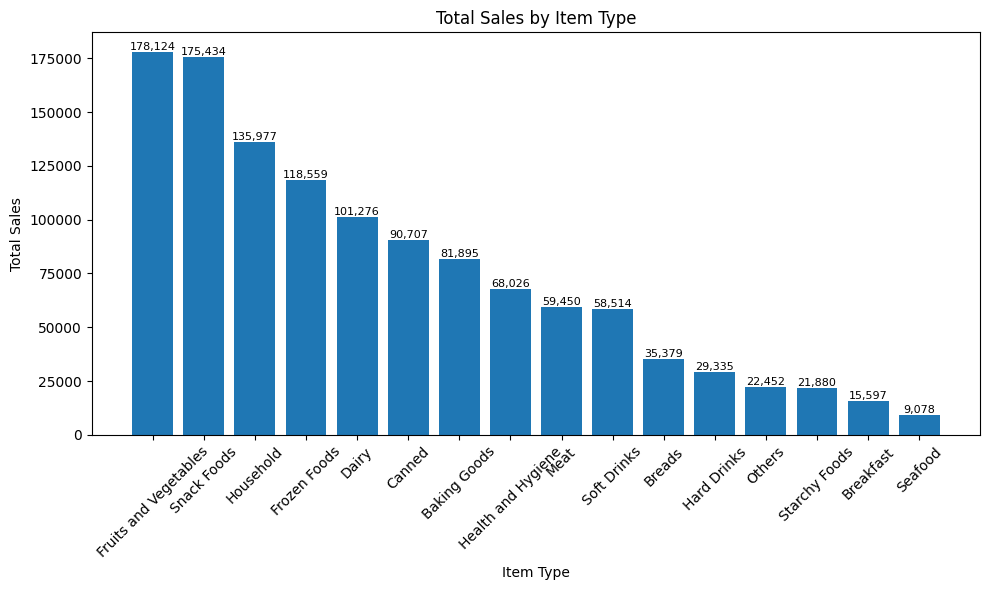

In [71]:
# Group and sort data
sales_by_type = (
    df.groupby('Item_Type')['Sales']
    .sum()
    .sort_values(ascending=False)
)

# Create figure
plt.figure(figsize=(10, 6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

# Labels and title
plt.xticks(rotation=45)
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.title("Total Sales by Item Type")

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()


## Total Content by Outlet for Total Sales

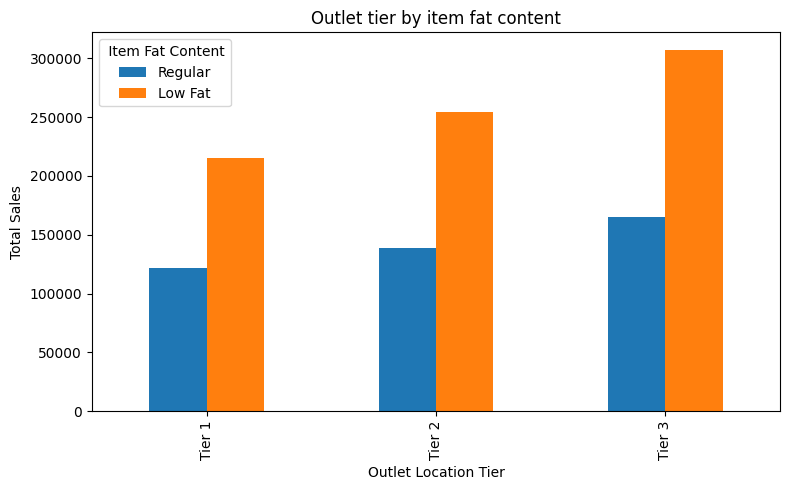

In [72]:
grouped =df.groupby(['Outlet Location Type' ,'Item_Fat_Content'])['Sales'].sum().unstack()
grouped=grouped[['Regular','Low Fat']]

ax= grouped.plot(kind='bar',figsize=(8,5),title='Outlet tier by item fat content')
plt.xlabel("Outlet Location Tier")
plt.ylabel("Total Sales")
plt.legend(title=" Item Fat Content")
plt.tight_layout()
plt.show()

## Total Sales by Outlet Establishment

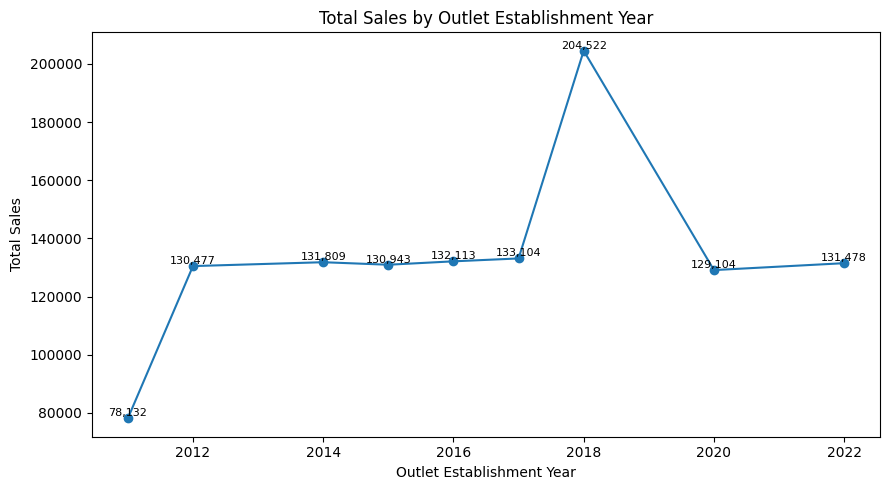

In [73]:
# Group by year and sum sales
sales_by_year = (
    df.groupby('Outlet_Establishment_Year')['Sales']
      .sum()
      .sort_index()
)

# Plot
plt.figure(figsize=(9, 5))
plt.plot(
    sales_by_year.index,
    sales_by_year.values,
    marker='o',
    linestyle='-'
)

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Total Sales by Outlet Establishment Year')

# Value labels
for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(
        x, y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()


# Sales by Outlet Size 

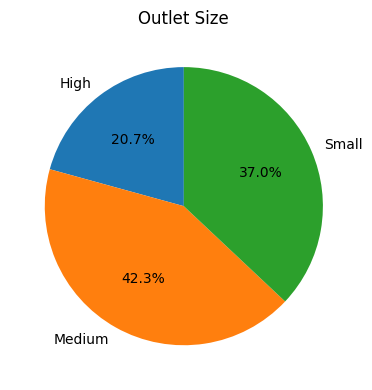

In [74]:
sales_by_size=df.groupby('Outlet_Size')['Sales'].sum()
plt.figure(figsize=(4,4))
plt.pie(sales_by_size, labels=sales_by_size.index,autopct='%1.1f%%',startangle=90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

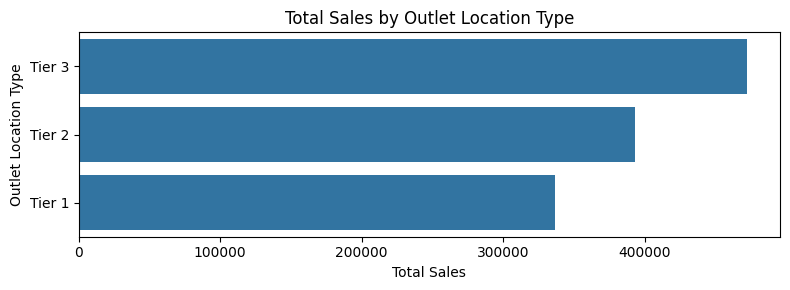

In [75]:
sales_by_location = df.groupby('Outlet Location Type') ['Sales'].sum().reset_index()

sales_by_location =sales_by_location.sort_values('Sales', ascending=False)

plt.figure(figsize=(8, 3)) # Smaller height, enough width

ax =sns.barplot(x='Sales', y='Outlet Location Type', data=sales_by_location)

plt.title('Total Sales by Outlet Location Type')

plt.xlabel('Total Sales')

plt.ylabel('Outlet Location Type')

plt.tight_layout() # Ensures Layout fits without scroll

plt.show()